In [1]:
import os.path as osp
import sys
sys.path.append('../')
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

import numpy as np
from tqdm.notebook import tqdm
#from sklearn import preprocessing, metrics
import types

import matplotlib
import matplotlib.pyplot as plt

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import utils

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


/home/mdrnevich/DESY/dev/ml4nw/SMEFT/../utils/__init__.py:5: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. 

  from . import plotting


In [2]:
DATA_NUM = ""
TEST_NUM = ""

source_file = "./data/SMEFT_SM_combined_tuple{}".format(DATA_NUM)
target_file = "./data/SMEFT_EFT_combined_tuple{}".format(DATA_NUM)

submodel_names = np.array(["Pos", "Neg", "Pos", "Neg"])
combos = [np.array((0,2)), #++
          np.array((0,3))] #+-

NUM_MODELS = 2

In [3]:
batch_sizes = [int(2**6), int(2**6)]
model_paths = [osp.join("models/classifier{}_subdensity_{}_batch{}.zip".format(TEST_NUM, ''.join(submodel_names[combos[i]]), batch_sizes[i])) for i in range(NUM_MODELS)]
training_settings = [utils.train.load_training_settings(model_path) for model_path in model_paths]
X_scalers, weight_norms = list(zip(*[utils.preprocessing.load_scaling(model_path) for model_path in model_paths]))
models = [utils.models.load_model(model_path, device=DEVICE).to(DEVICE) for model_path in model_paths]

In [4]:
source_positive_file = source_file + "_positives"
source_negative_file = source_file + "_negatives"
target_positive_file = target_file + "_positives"
target_negative_file = target_file + "_negatives"

files = [source_positive_file, source_negative_file, target_positive_file, target_negative_file]

sum_weights = []
for f in files:
    sum_weights.append(np.load(f + "_train.npy")[:,-1].sum())

sum_weights = np.array(sum_weights)
sum_weights

array([12994.654,     0.   , 16130.173, -3394.958], dtype=float32)

In [5]:
coefficient_init = [sum_weights[0] / sum_weights[:2].sum(), sum_weights[2] / sum_weights[2:].sum()]
coefficient_init

[1.0, 1.2665803]

In [6]:
t0 = 25619
t1 = 58
print(t0, t1, -(t0/t1)**2, -t0/t1)

train_base_dataset = utils.preprocessing.Dataset(source_file + "_train.npy", 0)
valid_base_dataset = utils.preprocessing.Dataset(source_file + "_val.npy", 0)

train_target_dataset = utils.preprocessing.Dataset(target_file + "_train.npy", 1)
valid_target_dataset = utils.preprocessing.Dataset(target_file + "_val.npy", 1)

25619 58 -195104.9824613555 -441.7068965517241


In [7]:
source_weight_norm = train_base_dataset.process(normalize_weights=True)
source_valid_weight_norm = valid_base_dataset.process(normalize_weights=True)

target_weight_norm = train_target_dataset.process(normalize_weights=True)
valid_target_dataset.process(normalize_weights=True)

tensor(0.0164)

In [8]:
train_generator_data = utils.preprocessing.CombinedDataset(train_base_dataset, train_target_dataset)
valid_generator_data = utils.preprocessing.CombinedDataset(valid_base_dataset, valid_target_dataset)

In [9]:
X_scaler, train_weight_norm = utils.preprocessing.get_scaling(train_generator_data)
_, valid_weight_norm = utils.preprocessing.get_scaling(valid_generator_data)
print(train_weight_norm, valid_weight_norm, train_weight_norm/valid_weight_norm)

100%|██████████| 350/350 [00:02<00:00, 162.16it/s]

tensor(1.0000) tensor(1.0000) tensor(1.0000)


In [10]:
@torch.no_grad()
def get_scores(model, loader, X_scaler, weight_norm=1, leave=False):
    if type(model) is not types.FunctionType:
        model.eval()
        loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_training(batch, X_scaler, weight_norm=weight_norm)
    else:
        loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_density(batch, weight_norm=weight_norm)

    score_list = []
    target_list = []
    weight_list = []
    t = tqdm(enumerate(loader), total=len(loader), leave=leave)
    for i, batch in t:
        target_list.append(batch[1])
        weight_list.append(batch[2])
        if type(model) is not types.FunctionType:
            x = batch[0].to(DEVICE)
        else:
            x = batch[0].to('cpu')
        batch_score = model(x)
        score_list.append(batch_score)
        t.refresh()  # to show immediately the update

    return torch.cat(score_list).cpu().numpy().flatten(), torch.cat(target_list).cpu().numpy().flatten(), torch.cat(weight_list).cpu().numpy().flatten()

In [11]:
batch_size = 1024
train_loader = DataLoader(train_generator_data, batch_size=batch_size, shuffle=False)
train_nominal_loader = DataLoader(utils.preprocessing.CombinedDataset(train_base_dataset), batch_size=batch_size, shuffle=False)
train_alternative_loader = DataLoader(utils.preprocessing.CombinedDataset(train_target_dataset), batch_size=batch_size, shuffle=False)

# Get the scores and study the distributions

In [12]:
train_scores, train_targets, train_weights = list(zip(*[get_scores(
    models[i],
    train_loader,
    X_scalers[i],
    leave=True
) for i in range(NUM_MODELS)]))

  0%|          | 0/1517 [00:00<?, ?it/s]

  0%|          | 0/1517 [00:00<?, ?it/s]

In [13]:
masks = [np.isclose(s, 1) for s in train_scores]
print([m.sum() for m in masks])

[0, 0]


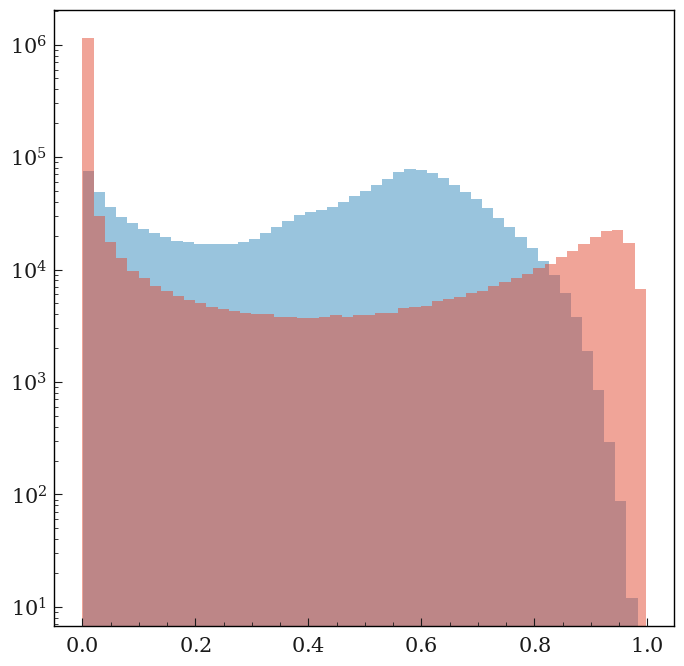

In [14]:
fig, ax = plt.subplots()
fig.set_size_inches(8,8)

ax.hist(train_scores[0], bins=50, alpha=0.5, density=False, log=True);
ax.hist(train_scores[1], bins=50, alpha=0.5, density=False, log=True);

# Now study the estimated likelihood ratio distributions

In [15]:
train_subratios = [train_scores[i] / (1-train_scores[i]) for i in range(NUM_MODELS)]
targets = torch.from_numpy(train_targets[0])
weights = torch.from_numpy(train_weights[0]) / train_weight_norm

In [16]:
def get_total_ratio(c0, c1, ratios):
    return c1 * ratios[0] + (1 - c1) * ratios[1]

In [17]:
def get_pare_loss(ratios, targets, weights, t0=t0, t1=t1):
    s = torch.from_numpy((t0 + t1 * ratios) / (t0**2 + t1**2 * ratios))
    return (utils.train.pare_loss(s, targets, t0, t1)*weights).mean().cpu().item()

def get_mse_loss(ratios, targets, weights):
    s = torch.from_numpy(ratios / (1 + ratios))
    return (F.mse_loss(s, targets, reduction='none')*weights).mean().cpu().item()

In [18]:
_ = get_total_ratio(*coefficient_init, train_subratios)
_.min(), _.max()

(-110.40662, 71.50534)

In [19]:
N = 100
losses1 = np.zeros(N)
y = np.linspace(coefficient_init[1]-0.3, coefficient_init[1]+0.3, N)

for i, c1 in enumerate(y):
    ratios = get_total_ratio(coefficient_init[0], c1, train_subratios)
    losses1[i] = get_pare_loss(ratios, targets, weights, t0=t0, t1=t1)

losses1 = np.array(losses1)

In [20]:
vmin1 = np.argmin(np.nan_to_num(losses1, nan=np.inf, neginf=np.inf))
y[vmin1]

1.3908227674888842

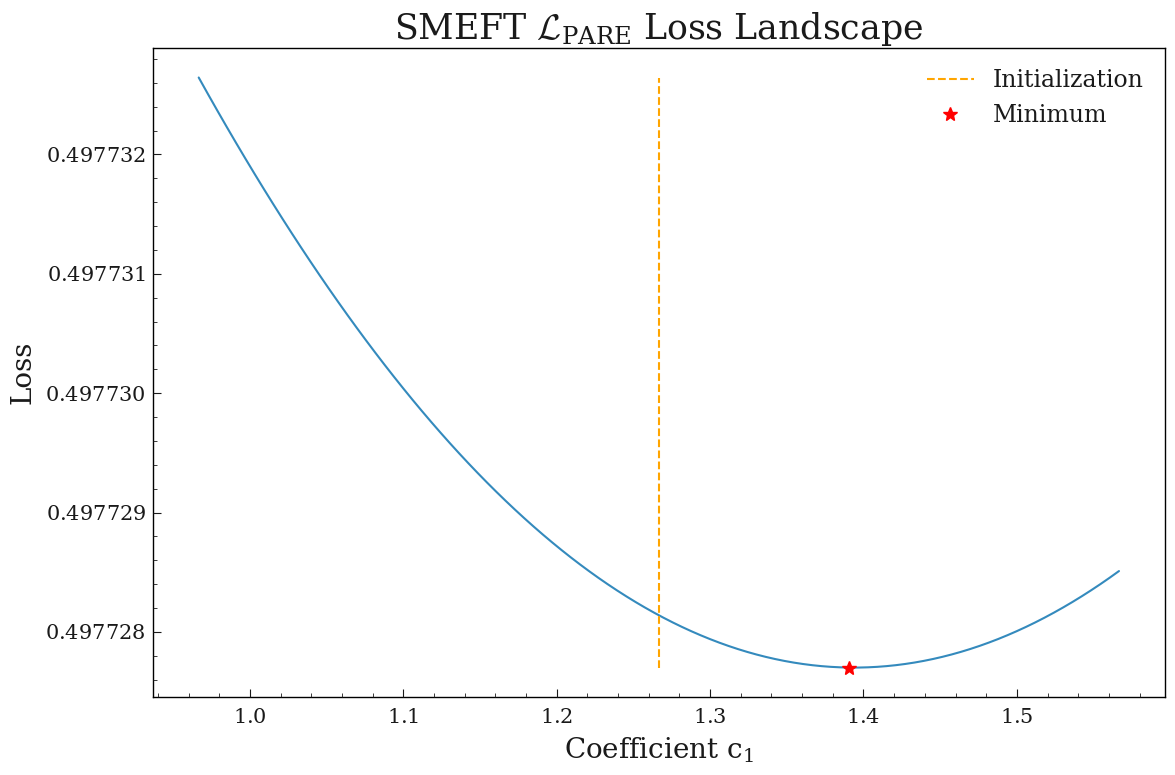

In [21]:
fig, ax = plt.subplots()
fig.set_size_inches(12,8)

ax.plot(y, losses1)
ax.plot([coefficient_init[1], coefficient_init[1]],
         [np.nan_to_num(losses1, nan=np.inf, neginf=np.inf).min(),
          np.nan_to_num(losses1, nan=-np.inf, posinf=-np.inf).max()], '--', c='orange', label="Initialization")
ax.plot(y[vmin1], losses1[vmin1], '*', c='red', label="Minimum", markersize=10)
ax.set_xlabel("Coefficient $c_1$", fontsize=20)
ax.set_ylabel("Loss", fontsize=20)
ax.set_title("SMEFT $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=25)
ax.legend(fontsize=17)

fig.tight_layout()

#fig.savefig("SMEFT_pare_loss_landscape.pdf")

In [22]:
N = 55
losses2 = np.zeros(N)
y = np.linspace(coefficient_init[1]-0.2, coefficient_init[1]+0.2, N)

for i, c1 in enumerate(y):
    ratios = get_total_ratio(coefficient_init[0], c1, train_subratios)
    #losses1[i] = get_loss(ratios, targets, weights, y0=y0, y1=y1)
    losses2[i] = get_mse_loss(ratios, targets, weights)

losses2 = np.array(losses2)

/tmp/ipykernel_6547/74352892.py:6: RuntimeWarning: divide by zero encountered in divide
  s = torch.from_numpy(ratios / (1 + ratios))


In [23]:
vmin2 = np.argmin(np.nan_to_num(losses2, nan=np.inf, neginf=np.inf))
y[vmin2]

1.1999136765797933

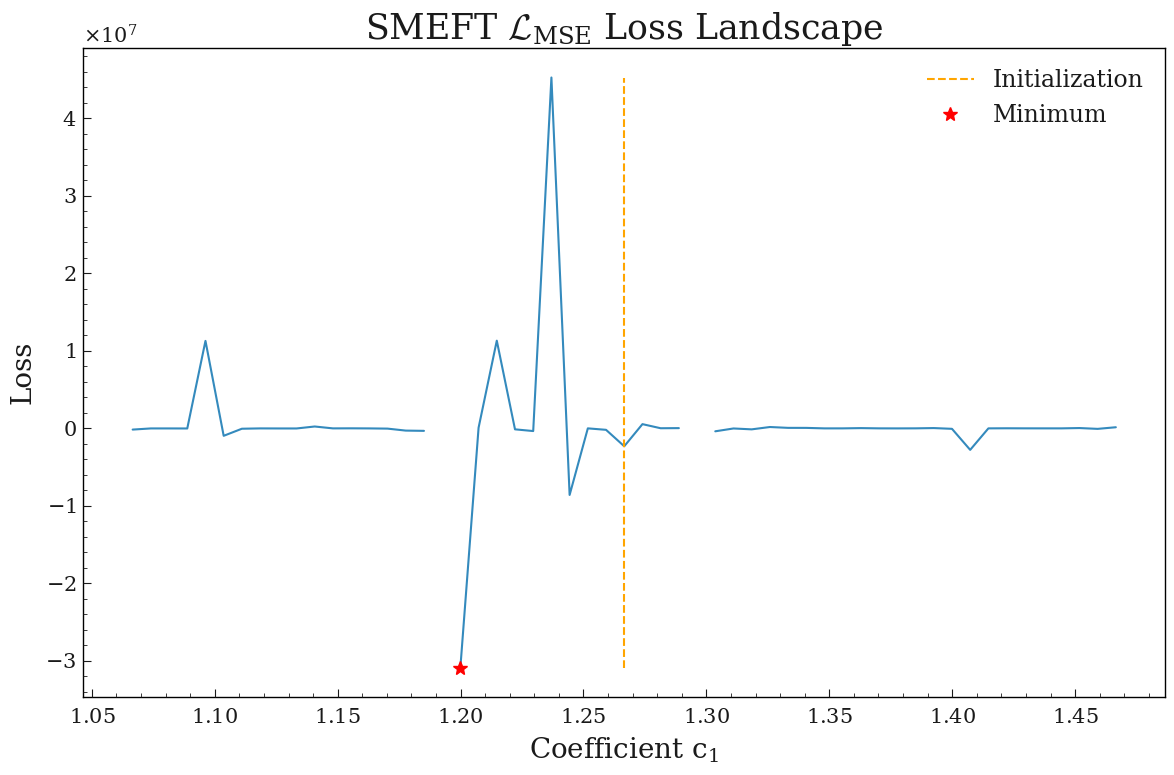

In [24]:
#fig = plt.figure(figsize=(10, 10))
#gs = matplotlib.gridspec.GridSpec(3, 2)
#ax = fig.add_subplot(gs[:2, :2])

fig, ax = plt.subplots()
fig.set_size_inches(12,8)

ax.plot(y, losses2)
ax.plot([coefficient_init[1], coefficient_init[1]],
         [np.nan_to_num(losses2, nan=np.inf, neginf=np.inf).min(),
          np.nan_to_num(losses2, nan=-np.inf, posinf=-np.inf).max()], '--', c='orange', label="Initialization")
ax.plot(y[vmin2], losses2[vmin2], '*', c='red', label="Minimum", markersize=10)
ax.set_xlabel("Coefficient $c_1$", fontsize=20)
ax.set_ylabel("Loss", fontsize=20)
ax.set_title("SMEFT $\mathcal{L}_{MSE}$ Loss Landscape", fontsize=25)
ax.legend(fontsize=17)

fig.tight_layout()

#fig.savefig("SMEFT_mse_loss_landscape.pdf")